In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys
import pickle

import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append('..')

from model import *
from utils import *
from dataset import *


from dask.diagnostics import ProgressBar

from ctxcore.rnkdb import FeatherRankingDatabase as RankingDatabase

from arboreto.utils import load_tf_names
from arboreto.algo import grnboost2
from arboreto.algo import genie3


from pyscenic.utils import modules_from_adjacencies, load_motifs
from pyscenic.prune import prune2df, df2regulons
from pyscenic.aucell import aucell


In [3]:
data = sc.read_h5ad('./data/perturb_filtered_gbm_crispri_crop.h5ad')

#remove treatment NA
na_rows = data.obs[data.obs['treatment'] == 'NA']
data = data[~data.obs.index.isin(na_rows.index)].copy()
data.obs['library_size'] = data.X.sum(axis=1)

In [4]:
percentile_99 = np.percentile(data.obs['library_size'], 99)
data = data[data.obs['library_size'] <= percentile_99].copy()

In [5]:
data = data[data.obs.top_sg == 'NTC']

In [6]:
df_genes = pd.DataFrame(data.X.toarray(), index=data.obs.index, columns=data.var.index)
tf_names = load_tf_names('./data/allTFs_hg38.txt')
tf_names = [tf for tf in tf_names if tf in df_genes.columns]

In [18]:
adjacencies = genie3(df_genes, tf_names=tf_names, verbose=True, seed=105) #seed 42 good

preparing dask client
parsing input
creating dask graph
8 partitions
computing dask graph
shutting down client and local cluster
finished


In [19]:
modules = list(modules_from_adjacencies(
    adjacencies=adjacencies,
    ex_mtx=df_genes,                
    # thresholds=(0.95,),            
    # top_n_targets=(),              
    # top_n_regulators=(),           
    # min_genes=40,                   
    rho_mask_dropouts=True          # ignore 0/0 cells in corr
))
len(modules)


2025-08-15 06:19:50,245 - pyscenic.utils - INFO - Calculating Pearson correlations.

2025-08-15 06:19:51,045 - pyscenic.utils - WARNING - Note on correlation calculation: the default behaviour for calculating the correlations has changed after pySCENIC verion 0.9.16. Previously, the default was to calculate the correlation between a TF and target gene using only cells with non-zero expression values (mask_dropouts=True). The current default is now to use all cells to match the behavior of the R verision of SCENIC. The original settings can be retained by setting 'rho_mask_dropouts=True' in the modules_from_adjacencies function, or '--mask_dropouts' from the CLI.
	Dropout masking is currently set to [True].

2025-08-15 06:19:53,675 - pyscenic.utils - INFO - Creating modules.


1020

In [20]:
rank_path = './data/hg38_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather'
def name(fname):
    return os.path.splitext(os.path.basename(fname))[0]
dbs = [RankingDatabase(fname=rank_path, name=name(rank_path))]
dbs

[FeatherRankingDatabase(name="hg38_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.rankings")]

In [ ]:
from ast import literal_eval

MOTIF_ANNOTATIONS_FNAME = './data/motifs-v10nr_clust-nr.hgnc-m0.001-o0.0.tbl'
MOTIFS_FNAME = './results/motifs.csv'
REGULONS_FNAME = "./results/regulons.p"

# Calculate a list of enriched motifs and the corresponding target genes for all modules.
with ProgressBar():
    df = prune2df(dbs, modules, MOTIF_ANNOTATIONS_FNAME)

tg = ('Enrichment','TargetGenes')
df[tg] = df[tg].apply(
    lambda x: [g for (g, _w) in (literal_eval(x) if isinstance(x, str) else x)]
)
# Create regulons from this table of enriched motifs.
regulons = df2regulons(df)

# Save the enriched motifs and the discovered regulons to disk.
df.to_csv(MOTIFS_FNAME)
with open(REGULONS_FNAME, "wb") as f:
    pickle.dump(regulons, f)

[                                        ] | 0% Completed | 15.88 sms

[                                        ] | 0% Completed | 46.23 s


2025-08-15 06:20:52,996 - pyscenic.transform - WARNING - Less than 80% of the genes in Regulon for ID2 could be mapped to hg38_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.rankings. Skipping this module.


[##################                      ] | 45% Completed | 151.58 s


2025-08-15 06:22:38,350 - pyscenic.transform - WARNING - Less than 80% of the genes in BANP could be mapped to hg38_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.rankings. Skipping this module.


[########################################] | 100% Completed | 207.54 s
Create regulons from a dataframe of enriched features.
Additional columns saved: []


In [ ]:
def merge_regulons_by_similarity(
    regulons,
    adjacencies,                  # DataFrame with ["TF","target","importance"]
    method: str = "dice",         # "dice" or "jaccard"
    threshold: float = None,      # similarity cutoff for merging
):
    """
    Merge TF-centric regulons into larger groups based on set similarity of targets.
    Returns: merged_regulons (list), S_df (TF×TF similarity matrix)
    """

    method = method.lower()
    if method not in {"dice", "jaccard"}:
        raise ValueError("method must be 'dice' or 'jaccard'")

    # reasonable defaults
    if threshold is None:
        threshold = 0.20 if method == "dice" else 0.10

    # Lookups -----
    tf_to_targets = {}
    tf_to_regulon = {}
    for r in regulons:
        tf = r.transcription_factor
        tf_to_regulon[tf] = r
        tf_to_targets[tf] = set(r.gene2weight.keys())

    adj_score = {
        (row["TF"], row["target"]): float(row["importance"])
        for _, row in adjacencies.iterrows()
    }

    # Similarity functions -----
    def dice(a: set, b: set) -> float:
        denom = len(a) + len(b)
        return (2.0 * len(a & b) / denom) if denom else 0.0

    def jaccard(a: set, b: set) -> float:
        if not a and not b:
            return 0.0
        inter = len(a & b)
        union = len(a | b)
        return inter / union if union else 0.0

    sim_fn = dice if method == "dice" else jaccard

    # Build TF×TF similarity matrix
    tfs = list(tf_to_targets.keys())
    S = np.zeros((len(tfs), len(tfs)), dtype=float)
    for i, tfi in enumerate(tfs):
        Ai = tf_to_targets[tfi]
        S[i, i] = 1.0
        for j in range(i + 1, len(tfs)):
            tfj = tfs[j]
            Aj = tf_to_targets[tfj]
            s = sim_fn(Ai, Aj)
            S[i, j] = s
            S[j, i] = s
    S_df = pd.DataFrame(S, index=tfs, columns=tfs)

    # Group TFs with union-find using the chosen similarity + threshold -----
    parent = {tf: tf for tf in tfs}
    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x
    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    for i, a in enumerate(tfs):
        for j in range(i + 1, len(tfs)):
            b = tfs[j]
            if S[i, j] >= threshold:
                union(a, b)


    return S_df, tf_to_targets



In [ ]:
S_df, tf_to_targets = merge_regulons_by_similarity(regulons,adjacencies,method="dice", threshold=0.20)

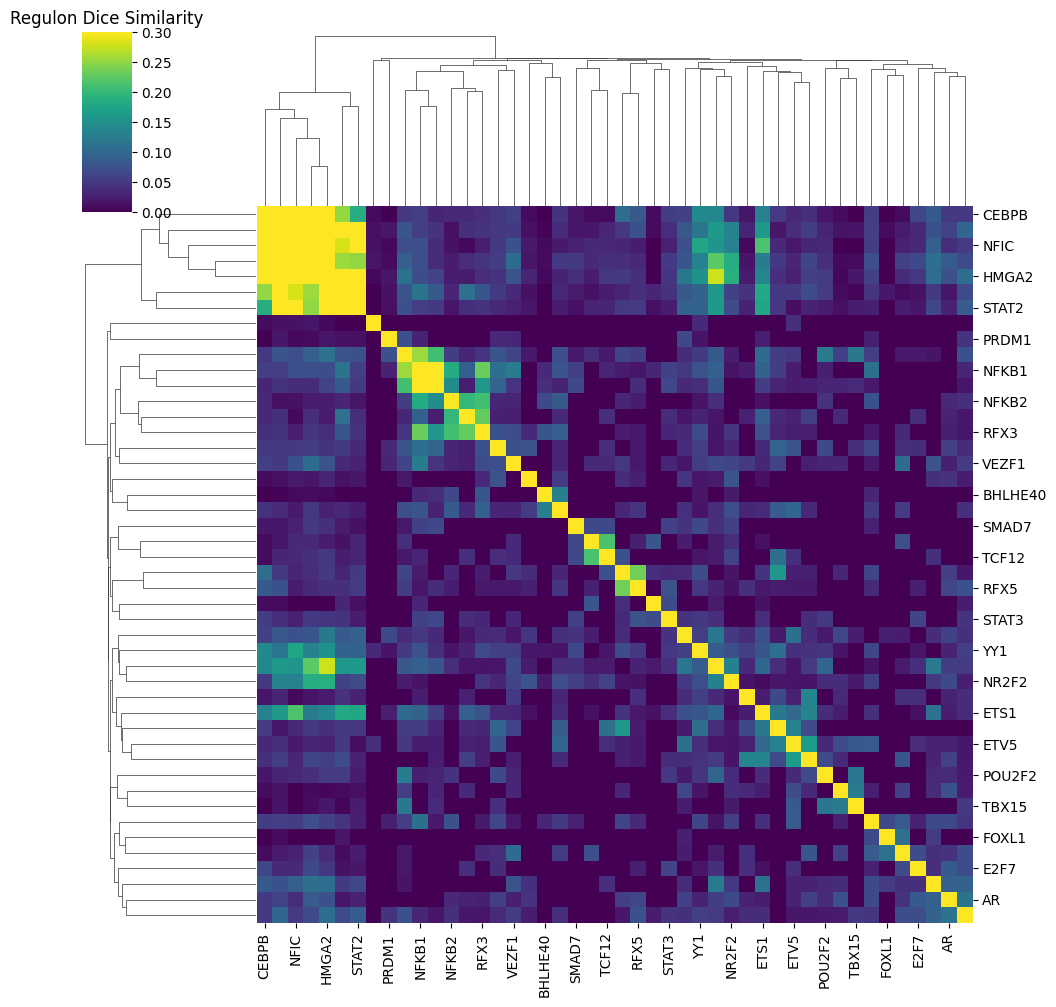

In [67]:
clustermap_dice = sns.clustermap(S_df, cmap='viridis', vmax=0.3, figsize=(10, 10))
plt.title("Regulon Dice Similarity")
plt.show()

In [ ]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

def cluster_tfs_fcluster(
    S_df: pd.DataFrame,                 # TF×TF similarity (Dice in [0,1])
    tf_to_targets: dict[str, set],      # TF -> set(targets)
    thresh: float,               
    linkage_method: str = "average",
    min_group_size: int = 1,            # set to 2 to drop singletons
    plot: bool = True,
    optimal_ordering: bool = True
):
    """
    Returns:
      modules: dict[int, (list_of_TFs, list_of_target_genes)]
      labels:  np.ndarray of 0-based cluster labels aligned to S_df.index
    """
    # --- TF order & checks ---
    tfs = list(S_df.index)
    assert list(S_df.columns) == tfs, "S_df rows/cols must be the same TF order."

    # --- similarity -> distance (1 - sim) ---
    S = S_df.values.astype(float)
    S = np.clip(S, 0.0, 1.0)
    np.fill_diagonal(S, 1.0)
    D = 1.0 - S
    np.fill_diagonal(D, 0.0)

    # --- build tree & (optionally) plot dendrogram ---
    Z = linkage(squareform(D, checks=False), method=linkage_method, optimal_ordering=optimal_ordering)
    dist_cut = thresh

    if plot:
        plt.figure(figsize=(10, 6))
        dendrogram(
            Z, labels=tfs, leaf_rotation=90,
            color_threshold=dist_cut, above_threshold_color="grey"
        )
        plt.title(f"Regulon clustering ({linkage_method} linkage)")
        plt.ylabel("Distance")
        plt.axhline(y=dist_cut, linestyle="--")
        plt.tight_layout()
        plt.show()

    # --- cut the SAME tree with fcluster at the SAME distance threshold ---
    labels_1based = fcluster(Z, t=dist_cut, criterion="distance")
    # make 0-based, stable
    base = labels_1based.min()
    labels = labels_1based - base

    # --- pack into modules dict ---
    modules = {}
    uniq = sorted(np.unique(labels))
    remap = {old: new for new, old in enumerate(uniq)}
    for old_lbl in uniq:
        idxs = np.where(labels == old_lbl)[0]
        if len(idxs) < min_group_size:
            continue
        group_tfs = [tfs[i] for i in idxs]
        group_targets = sorted(set().union(*(tf_to_targets[tf] for tf in group_tfs)))
        modules[remap[old_lbl]] = (group_tfs, group_targets)

    return modules, labels


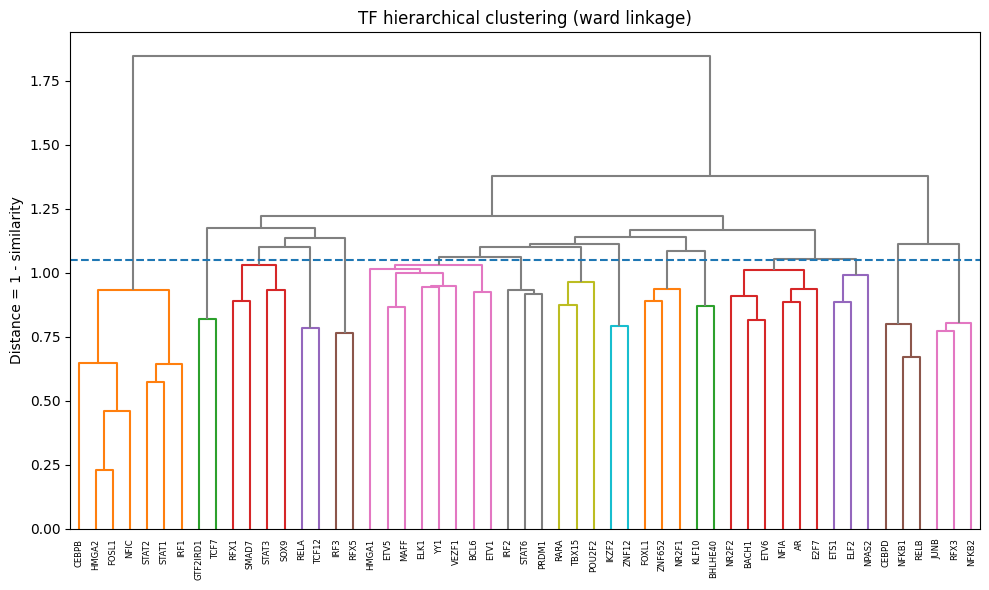

In [26]:
modules, labels = cluster_tfs_fcluster(
    S_df=S_df,
    tf_to_targets=tf_to_targets,
    thresh=1.05,     # try a few after seeing the dendrogram
    linkage_method="ward",
    min_group_size=1,
    plot=True
)

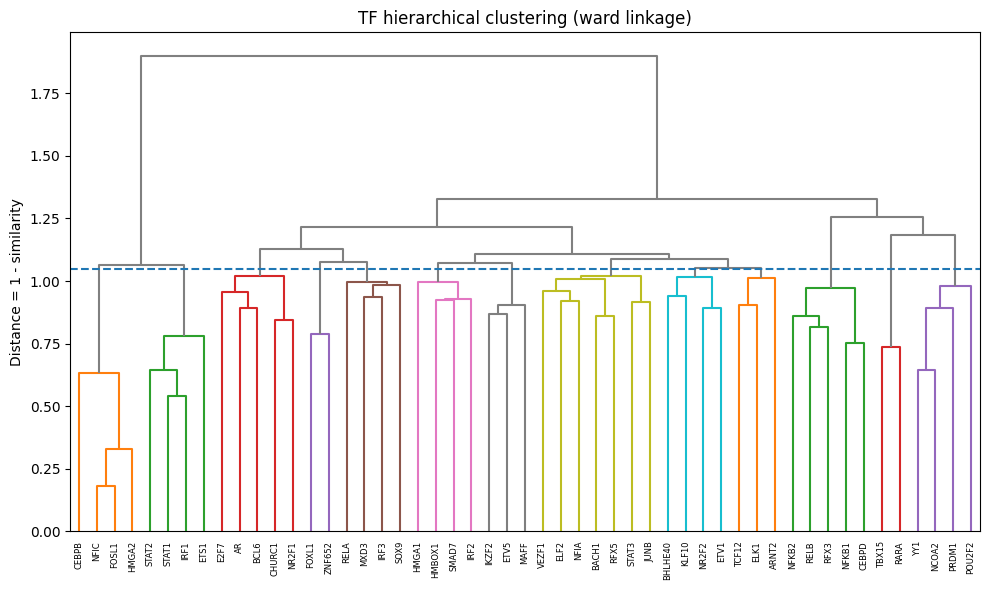

In [16]:
modules, labels = cluster_tfs_fcluster(
    S_df=S_df,
    tf_to_targets=tf_to_targets,
    thresh=1.05,     # try a few after seeing the dendrogram
    linkage_method="ward",
    min_group_size=1,
    plot=True
)

In [33]:
intersection = S_df.index.intersection(S_test.index)
S_df = S_df.loc[intersection, intersection]
S_test = S_test.loc[intersection, intersection]

In [36]:
from scipy.stats import pearsonr

# Flatten the matrices
flattened_df = S_df.values.flatten()
flattened_test = S_test.values.flatten()

# Calculate Pearson correlation
correlation, _ = pearsonr(flattened_df, flattened_test)

print(f"Pearson correlation between two runs: {correlation}, {S_df.shape[0]} shared regulons")

Pearson correlation between two runs: 0.9753676143652126, 46 shared regulons


In [17]:
S_test = S_df.copy()

In [65]:
# Extract the set of genes from the data
data_genes = set(data.var.index)

# Create a set to store the keys from modules
module_gene_sets = set()

# Iterate through the modules dictionary
for key, value in modules.items():
    # Convert the tuple of arrays into a set of strings
    gene_set = set(value[1])  # Assuming the second element of the tuple contains the genes
    tf_set = set(value[0])  # Assuming the first element of the tuple contains the TFs
    module_gene_sets = module_gene_sets.union(gene_set)  # Add the gene set to the module_gene_sets
    module_gene_sets = module_gene_sets.union(tf_set)  # Add the TF set to the module_gene_sets

common_genes = data_genes.intersection(module_gene_sets)
total_genes = data.shape[1]
# Print the results
print(f"Number of common genes: {len(common_genes)}")
print(f"Number of total genes: {total_genes}")

Number of common genes: 1443
Number of total genes: 2218


In [63]:
from collections import Counter

# Collect all genes from all modules
all_genes = []
for key, value in modules.items():
    all_genes.extend(value[1])  # Assuming the second element of the tuple contains the genes

# Count occurrences of each gene
gene_counts = Counter(all_genes)

# Find duplicate genes
duplicate_genes = {gene: count for gene, count in gene_counts.items() if count > 1}

# Print the results
if duplicate_genes:
    print(f"Duplicate genes found across modules: {len(duplicate_genes)}")
    print(f"Mean number of duplicates: {np.mean(list(duplicate_genes.values()))}")
    print(duplicate_genes)
else:
    print("No duplicate genes found across modules.")

Duplicate genes found across modules: 697
Mean number of duplicates: 2.5538020086083213
{'AAR2': 3, 'ABCC5': 3, 'ABI1': 2, 'ABL2': 2, 'ACOT7': 3, 'ACSL5': 2, 'ACTR3': 2, 'ACYP1': 4, 'ADAM12': 2, 'ADAM17': 2, 'ADAMTSL1': 2, 'ADAMTSL4-AS1': 3, 'ADAR': 2, 'AFF3': 2, 'AGL': 3, 'AHI1': 2, 'AIM2': 2, 'ALAD': 3, 'ALCAM': 2, 'ALDOA': 2, 'ALG10B': 2, 'AMPD3': 2, 'ANKH': 2, 'ANKMY2': 2, 'ANKRD29': 3, 'ANO10': 2, 'ANXA6': 2, 'AP5B1': 2, 'APBB2': 2, 'APOLD1': 4, 'APP': 2, 'ARHGAP42': 2, 'ARHGDIA': 2, 'ARHGEF2': 3, 'ARHGEF6': 4, 'ARID2': 3, 'ASAP1': 2, 'ASNS': 3, 'ATAD2': 2, 'ATAD5': 2, 'ATP1A1': 2, 'ATP1B3': 2, 'ATP6V1A': 2, 'ATXN7': 3, 'AURKAIP1': 4, 'BACE1': 4, 'BAG3': 3, 'BANF1': 2, 'BASP1': 2, 'BATF2': 3, 'BCL11B': 4, 'BICC1': 5, 'BIN1': 2, 'BIRC3': 2, 'BIRC6': 2, 'BMPR1B': 2, 'BMS1': 2, 'BNC2': 2, 'BOD1': 2, 'BPNT1': 3, 'BRD2': 2, 'C10orf76': 2, 'C14orf159': 3, 'C1QTNF1': 4, 'C2CD2': 2, 'C7orf50': 2, 'CAAP1': 3, 'CADPS2': 3, 'CANX': 2, 'CAPG': 3, 'CARHSP1': 2, 'CASC4': 2, 'CASP4': 2, 'CASP8':